# Lab 2 - Diffusion Models

Diffusion models have recently emerged as a new high-performance family of deep generative models. They are incredibly good at a wide range of applications, including image synthesis, video generation, and molecule generation (e.g for drug discovery), to mention a few.

Diffusion models are a family of probabilistic generative models that gradually degrade data by injecting noise, and then learn to reverse this process to generate new samples. There are two closely related formulations: denoising diffusion probabilistic models (DDPM), and score-based generative models (SGMs). Score-based models are currently very popular at the research frontier, not least because they enable generalizing the idea of diffusion models to so-called flow matching. However, in this lab we are going to focus on DDPMs since they are quite intuitive and provide a good foundation for developing a more in-depth understanding of diffusion models, including more advanced formulations.

## Preparation exercies 📝
As part of the preparation for the lab, you have derived many results that you saw on the lecture and that you will use in your implementation. Whenever these results show up in the instructions, this will be indicated by 📝

## Denoising Diffusion Probabilistic Models (DDPMs)

DDPMs are an approach to generate new data samples. They work by using two Markov processes (a type of stochastic processes used to model sequences of random variables): a forward chain that adds noise to the data, and a backward chain that turns the noise into data. The goal is to transform the data distribution into a simple distribution (such as a standard Gaussian distribution). This is done using a simple linear Gaussian Markov process. Next, we build a backward Markov process that learns to reverse the forward process and generate new data from pure noise. Specifically, we first sample a noise vector from the simple distribution, and then apply the backward Markov kernel to gradually transform the noise into data.

Training the DDPM involves adjusting the parameters of the backward Markov kernel so that it closely matches the inversion of the forward Markov process. The difference between the two processes can for instance be measured using the Kullback-Leibler (KL) divergence and the parameters are adjusted to minimize this difference. This turns out to be a sum of weighted L2 reconstruction losses. In practice it is common to discard the weights and minimize an unweighted sum of reconstruction losses instead, so the training objective (as given in the lectures) ends up being a denoising objective where we train the network to predict the clean data point from the noisy version. The main difference from a standard denoising autoencoder, for instance, is that we train the same network to denoise from all possible noise levels, from high to low.

### In more detail...

The training procedure is as follows. First we define a noise schedule $\{ \beta_{t} \}_{t=1}^T$ 📝. Then, each training iteration consists of:

1. Sample a batch of training images. For each image $x_0$ in the input batch:
2. Sample a random $t \sim \text{Uniform}({1, ..., T})$
3. Sample a noisy sample $\mathbf{x}_t$ from $q(\mathbf{x}_t|\mathbf{x}_0)$ by (see also note below): 📝
    - Sample a random Gaussian noise that has the same dimension as the input data: $\epsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
    - Add the noise to the clean input using equation: $\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$. 📝
4. Train the model $\epsilon_\theta(x_t, t)$ to learn the noise by minizing the following loss: $\mathcal{L} = \sum\|\epsilon_\theta(\mathbf{x}_t, t) - \epsilon\|^2$


The generative procedure is as follows:

1. Sample a random Gaussian noise that has the same dimension as the input data: $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. Go one step back by the following equations:
    - resconstruct $\hat{\mathbf{x}}_0 \approx \mathbf{x}_0$ from predicted noise $\hat \epsilon = \epsilon_\theta(\mathbf{x}_t, t)$. 📝
    - simulate from the conditional distribution $ q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0) $ by conditioning on the reconstructtion $\mathbf{x}_0 = \hat{\mathbf{x}}_0$ 📝

#### Note: Sampling from a Gaussian distribution with diagonal covariance
This lab will include a lot of sampling from Gaussian distributions where the covariance matrices are diagonal. While PyTorch provides support for a large number of distributions, for the special case of Gaussian with diagonal covariance, we can do this without creating special ```torch.distributions``` objects by noting that
$$
\mathbf{x} \sim \mathcal{N}(\mathbf{x}|\mathbf{\mu}, \sigma^2I) \iff \mathbf{x} = \mathbf{\mu} + \sigma \epsilon, \quad \epsilon \sim\mathcal{N}(\epsilon|\mathbf{0}, \mathbf{I})
$$
Notice that in the left hand side, the covariance includes $\sigma^2$, while in the right hand side, we use $\sigma$ (i.e., without the square).

This might not look easier than before (we still need to sample $\epsilon$), but sampling from $\mathcal{N}(\mathbf{0}, \mathbf{I})$ is very easy: it is enough to just sample D independent variables from a standard (univariate) Gaussian distribution $\mathcal{N}(0, 1)$ (where D is the dimension of $\epsilon$ and $\mathbf{x}$). In torch, if the mean is stored in a tensor ```mu```, this sampling can be obtained by ```epsilon = torch.randn_like(mu)```. This will create a new tensor with the exact same dimensions as ```mu``` (and on the same device), and where each element is an independent draw from a $\mathcal{N}(0, 1)$ distribution. Hence, sampling from $\mathcal{N}(\mathbf{x}|\mathbf{\mu}, \sigma^2\mathbf{I})$ can in torch be done by
```
x = mu + sigma * torch.randn_like(mu)
```
(if you instead want to specify the dimensions and device of $\epsilon$ yourself, you can use ```torch.randn```)

This _reparametrization_ of the Gaussian distribution is used above in step 3 in the training procedure. Essentially, instead of having the neural network predict $\mathbf{x}_0$, it just predicts the noise $\epsilon$ that is added in step 3 to get the noisy image, and the prediction of noise is what is used in the generative procedure. The same reparametrization is also used in other generative models, like the Variational Autoencoder (VAE)

## Tasks to Complete:

1. **Generate 2D data**

  In this task you are given a 2D dataset called Two Moons. The dataset consists of 2D points with coordinates $(x_i, y_i)$. The collection of the points in 2D form a two-moon like shape. (Note that $y$ does not refer to an output or conditioning variable for this data set. It is simply the second coordinate of the 2-dimensional data vector, $\mathbf{x} = [x,y]$).

2. **Generate handwritten digits**

  In this task we use the MNIST dataset. The dataset consists of images of handwritten digits. You are supposed to generate specific digits based on your input via conditional generation.

## Lets start coding 🤗

Import important libraries that will be used in this lab.

In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Lambda, Pad
from torchvision.datasets.mnist import MNIST
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

## Task 1: Generating 2D data

#### 1.1. Visualize the dataset:

We will start with a simple two-dimensional dataset for you to get familar with the diffusion generative model.
Run the following code to define the dataset and visualize it.

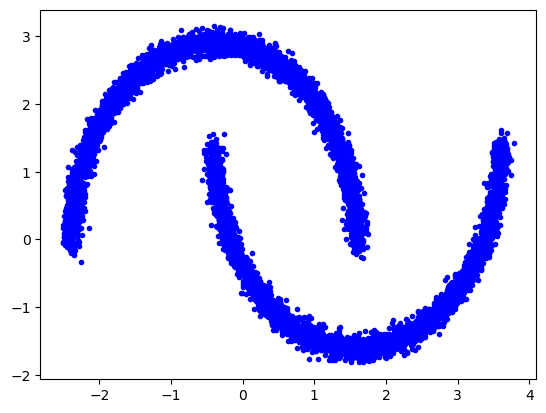

In [3]:
def moons_dataset(n=8000):
    X, _ = make_moons(n_samples=n, random_state=42, noise=0.03)
    X[:, 0] = (X[:, 0] + 0.3) * 2 - 1
    X[:, 1] = (X[:, 1] + 0.3) * 3 - 1
    plt.plot(X[:, 0], X[:, 1], 'b.')
    return torch.from_numpy(X.astype(np.float32))

dataset = moons_dataset(n=8000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

#### 1.2. Overall Architecture:

For the simple task, a simple multilayer perceptron (MLP) is employed to define the generative model.
The overal architecture is given below:
The $x$ coordinate, $y$ coordinate, and the $t$ timestep are first passed through *positional embeddings*. The output are concatenated together. *Linear* layers and *GeLUs* (non-linear layers) and residual connections are employed to get the final output.

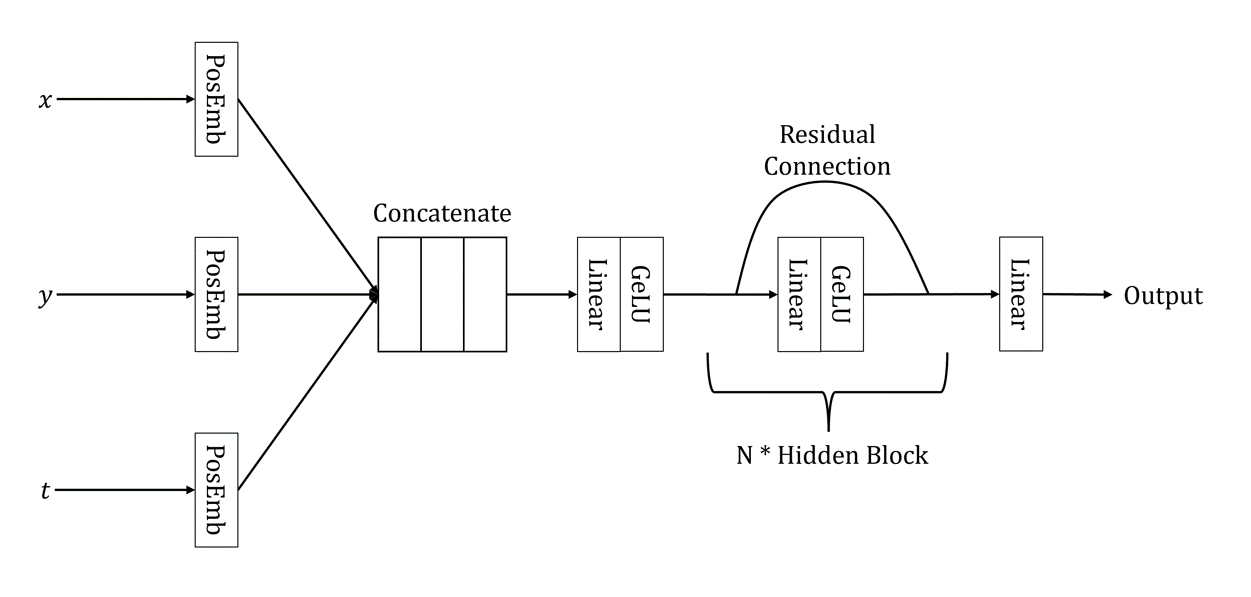

**Question 0:** What should the dimension of the output be? Complete the code block below with a linear output layer of the correct dimension.

**Answer:**

In [4]:
class PositionalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.tensor(10000.0, device=x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size, device=x.device))
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

class Block(nn.Module):
    def __init__(self, size: int):
        super().__init__()

        self.ff = nn.Linear(size, size)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor):
        return x + self.act(self.ff(x))

class MLP(nn.Module):
    def __init__(self, hidden_size: int = 128, hidden_layers: int = 3, emb_size: int = 128,
                 scale: int = 25):
        super().__init__()

        self.time_mlp = PositionalEmbedding(emb_size)
        self.input_mlp1 = PositionalEmbedding(emb_size, scale)
        self.input_mlp2 = PositionalEmbedding(emb_size, scale)

        concat_size = self.time_mlp.size + self.input_mlp1.size + self.input_mlp2.size
        layers = [nn.Linear(concat_size, hidden_size), nn.GELU()]
        for _ in range(hidden_layers):
            layers.append(Block(hidden_size))
        # Append a Linear output layer
        layers.append(nn.Linear(hidden_size, 2)) #<--- Task 0 answer here, output has 2 dimensions (x, y) like input data points
        self.joint_mlp = nn.Sequential(*layers)

    def forward(self, x, t):
        x1_emb = self.input_mlp1(x[:, 0])
        x2_emb = self.input_mlp2(x[:, 1])
        t_emb = self.time_mlp(t)
        x = torch.cat((x1_emb, x2_emb, t_emb), dim=-1)
        x = self.joint_mlp(x)
        return x

#### 1.3. Construct Denoising Diffusion Probabilistic Model (DDPM)

Now we construct the DDPM class. You need to define several important variables and complete the functions as stated below.

*   noiseScheduler: Construct the noise schedule: $\beta_{1},...,\beta_{T}$. 📝

*   For convenience, we precompute and store several variables from $\beta_t$. Specifically, for $t=1,\dots,T$ we store 1d arrays with $\{\alpha_t\}$, $\{\bar{\alpha}_t\}$, $\{\bar{\alpha}_{t-1}\}$, $\{\sqrt{\bar{\alpha}_{t}}\}$, $\{\sqrt{1-\bar{\alpha}_{t}}\}$. 📝

*   We also precompute the coefficients $a_t^{(1)}, a_t^{(2)}, b_t^{(1)}, b_t^{(2)}$ used to compute $\tilde{\mu}_{t}(\mathbf{x}_{t},\mathbf{x}_{0})$ and $\hat{\mathbf{x}}_{0}$: 📝
    -    $\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0) = a_t^{(1)} \mathbf{x}_0 + a_t^{(2)} \mathbf{x}_t$ 📝
    -    $\hat{\mathbf{x}}_0 = b_t^{(1)} \mathbf{x}_t - b_t^{(2)} \epsilon_\theta(\mathbf{x}_t, t)$ (notice the minus sign before $\epsilon$)📝

*   add_noise: Add noise to the input data according to the noise schedule.

*   q_posterior: Compute posterior mean: $\tilde{\mu}_{t}(\mathbf{x}_t,\mathbf{x}_0)$. 📝

*   get_variance: Compute posterior variance: $\tilde{\beta}_{t}$. 📝

*   reconstruct_x0: Compute resconstructed input $\hat{\mathbf{x}}_{0}$ from the predicted noise. 📝

*   sample_timesteps: randomly sample timestep for training the diffusion model: $t \in \text{Uniform}({1, ..., T})$.

*   step: Reverse process for generation, sample $\mathbf{x}_{t-1}$ based on $\mathbf{x}_{t}$ and the model output (predicted noise).

In [5]:
class ddpm():
    def __init__(self,
                 num_timesteps=50,
                 beta_start=0.0001,
                 beta_end=0.02,
                 beta_schedule='linear'
                 ):
        # Initialize variables
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta_schedule = beta_schedule

        # Initialize noise schedule betas
        # this should have a dimension of [num_timesteps + 1]
        self.betas = self.noiseScheduler().to(self.device)

        # alpha, alphas_cumprod, alphas_cumprod_prev
        # Each of these variables should have the same dimension as betas [num_timesteps + 1]
        # alphas_cumprod is the comulatetive product of alphas: $\bar{\alpha}_{t}$
        # alphas_cumprod_prev stores a shifted version of alphas_cumprod: $\bar{\alpha}_{t-1}$.
        # for this shifted array don't forget to pad a 1. for the first element using F.pad
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        #Slicing alphas_cumprod to remove last element, then padding 1 at start
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # compute variables required for function self.add_noise
        # Each of these variables should have the same dimension as betas [num_timesteps + 1]
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # compute variables required for function self.q_posterior
        # Each of these variables should have the same dimension as betas [num_timesteps + 1]
        #This seems to be coeff for x_0 and coeff for x_t that we calculated in task 3 of prep. questions?
        self.posterior_mean_coef1 = torch.sqrt(self.alphas_cumprod_prev) * self.betas / (1.0 - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1.0 - self.alphas_cumprod)

        # compute variables required for function self.reconstruct_x0
        # Each of these variables should have the same dimension as betas [num_timesteps + 1]
        self.reconstruct_x0_coef1 = (1.0 / self.sqrt_alphas_cumprod)
        self.reconstruct_x0_coef2 = self.sqrt_one_minus_alphas_cumprod / self.sqrt_alphas_cumprod

        self._init_dim()  # fix dimensions of the coefficients
    
    def _init_dim(self):
        # For following operations we need to expand the dimensions of these variables to [num_timesteps + 1,1]
        self.alphas = self.alphas[:,None]
        self.alphas_cumprod = self.alphas_cumprod[:,None]
        self.alphas_cumprod_prev = self.alphas_cumprod_prev[:,None]
        self.sqrt_alphas_cumprod = self.sqrt_alphas_cumprod[:,None]
        self.sqrt_one_minus_alphas_cumprod = self.sqrt_one_minus_alphas_cumprod[:,None]
        self.posterior_mean_coef1 = self.posterior_mean_coef1[:,None]
        self.posterior_mean_coef2 = self.posterior_mean_coef2[:,None]
        self.reconstruct_x0_coef1 = self.reconstruct_x0_coef1[:,None]
        self.reconstruct_x0_coef2 = self.reconstruct_x0_coef2[:,None]

    # construct noise beta scheduler
    # you are supposed to construct a linear beta scheduler
    # input: 
    # output: a variable called 'betas' that has a dimension of [num_timesteps + 1]
    # NOTE: to get indexing correct, first create a tensor with beta_1 to beta_T, then add a single 0 as padding to the beginning
    # With this padding, betas[t] will indeed return beta_t, and use 0 as "no noise is added to x_0"
    # this will ensure that alpha_0 = 1 and alpha_bar_0 = 1
    def noiseScheduler(self):
        betas = torch.linspace(self.beta_start, self.beta_end, self.num_timesteps)
        betas = F.pad(betas, (1, 0), value=0.0)
        assert len(betas) == self.num_timesteps + 1
        return betas

    # sample forward process, x_t ~ q(x_t | x_0)
    # inputs: x_0(input data), noise(random sampled noise), and t(random sampled timestep)
    # output: x_t(noisy data)
    # dimensions:
    # x_0: [batch_size, D]
    # noise: [batch_size, D]
    # t: [batch_size]
    # x_t: [batch_size, D]
    # hint: Think about which equation is implemented here. Make use of the variables we defined above
    def add_noise(self, x_0, noise, t):
        xt = torch.sqrt(self.alphas_cumprod[t]) * x_0 + self.sqrt_one_minus_alphas_cumprod[t] * noise
        return xt

    # diffusion process posteriors mean $q(x_{t-1} | x_t, x_0)$
    # input: x_0(reconstructed input data), x_t(noisy data from forward process), and t(current timestep)
    # output: mu(posteriors mean)
    # dimensions:
    # x_0: [batch_size, D]
    # x_t: [batch_size, D]
    # t: scalar
    # mu: [batch_size, D]
    # hint: Think about which equation is implemented here. Make use of the variables we defined above.
    def q_posterior(self, x_0, x_t, t):
        mu = self.posterior_mean_coef1[t] * x_0 + self.posterior_mean_coef2[t] * x_t
        return mu

    # diffusion process posteriors variance $q(x_{t-1}|x_{t},x_{0})$
    # input: t(current timestep)
    # output: variance(posteriors variance)
    # dimensions:
    # t: scalar
    # variance: scalar
    # hint: Think about which equation is implemented here. Make use of the variables we defined above.
    def get_variance(self, t):
        variance = (1.0 - self.alphas_cumprod_prev[t]) / (1.0 - self.alphas_cumprod[t]) * self.betas[t]
        return variance

    # reconstruct input data x_0
    # input: x_t(noisy data from forward process), t(current timestep), and pred_noise(predicted noise from model output)
    # output: x_0(reconstructed input data)
    # dimensions:
    # x_t: [batch_size, D]
    # t: scalar
    # pred_noise: [batch_size, D]
    # x_0: [batch_size, D]
    # hint: Think about which equation is implemented here. Make use of the variables we defined above.
    def reconstruct_x0(self, x_t, t, pred_noise):
        x0 = self.reconstruct_x0_coef1[t] * x_t - self.reconstruct_x0_coef2[t] * pred_noise
        return x0

    # sample timesteps for training
    # input: n(batch size)
    # output: randomly sampled integers
    # dimensions:
    # n: scalar
    # output: [batch_size]
    # hint: use torch.randint to select random integers for training (remember that the argument 'high' is exclusive, so use +1 to include num_timesteps)
    def sample_timesteps(self, n):
        t = torch.randint(low=1, high=(self.num_timesteps+1), size=n, device=self.device)
        return t

    # one step backward during sampling (generation)
    # functions needed: reconstruct_x0, q_posterior
    # input: pred_noise(predicted noise from model output), t(current time step), x_t(sample from the last step)
    # output: prev_sample
    # dimensions:
    # pred_noise: [batch_size, D]
    # t: scalar
    # sample: [batch_size, D]
    # prev_sample: [batch_size, D] (input to the next loop)
    def step(self, pred_noise, t, x_t):
        z = torch.randn_like(x_t) # Gaussian noise that is "driving" the backward process
        mean = self.q_posterior(self.reconstruct_x0(x_t, t, pred_noise), x_t, t)
        variance = self.get_variance(t)
        # sample based on posterior and variance
        prev_sample = mean + (variance ** 0.5) * z

        return prev_sample

**Question 1:** What is `mean` and `variance` when `t==0`? 📝

**Answer:**
alpha_0 = 1
beta_0 = 0


**Demo 1:** Run the following code to check the parameters.

In [ ]:
diffusion = ddpm(num_timesteps=50, beta_start=0.0001, beta_end=0.02, beta_schedule='linear')

t = 20  # timestep to check

# Expected values
exp_betas                   = 0.0078
exp_alphas                  = 0.9922
exp_alphas_cumprod          = 0.9237
exp_alphas_cumprod_prev     = 0.9310
exp_sqrt_alphas_cumprod     = 0.9611
exp_sqrt_one_minus          = 0.2762
exp_post_mean_coef1         = 0.0988
exp_post_mean_coef2         = 0.9011
exp_recon_x0_coef1          = 1.0405
exp_recon_x0_coef2          = 0.2874

# Helper for numeric comparison
def check(name, value, expected, tol=1e-4):
    if abs(float(value) - float(expected)) >= tol:
        raise AssertionError(
            f"{name} failed: your value was {float(value):.4f}, "
            f"expected {expected:.4f}. Check your code for errors."
        )

# Assertions with error messages
check("betas[20]",                   diffusion.betas[t],                   exp_betas)
check("alphas[20]",                  diffusion.alphas[t],                  exp_alphas)
check("alphas_cumprod[20]",          diffusion.alphas_cumprod[t],          exp_alphas_cumprod)
check("alphas_cumprod_prev[20]",     diffusion.alphas_cumprod_prev[t],     exp_alphas_cumprod_prev)
check("sqrt_alphas_cumprod[20]",     diffusion.sqrt_alphas_cumprod[t],     exp_sqrt_alphas_cumprod)
check("sqrt_one_minus_alphas_cumprod[20]", diffusion.sqrt_one_minus_alphas_cumprod[t], exp_sqrt_one_minus)
check("posterior_mean_coef1[20]",    diffusion.posterior_mean_coef1[t],    exp_post_mean_coef1)
check("posterior_mean_coef2[20]",    diffusion.posterior_mean_coef2[t],    exp_post_mean_coef2)
check("reconstruct_x0_coef1[20]",    diffusion.reconstruct_x0_coef1[t],    exp_recon_x0_coef1)
check("reconstruct_x0_coef2[20]",    diffusion.reconstruct_x0_coef2[t],    exp_recon_x0_coef2)

print("✅ All DDPM parameter tests passed!")

**Demo 2:** Plot how $\beta_t$ depends on the time t. First you need to define the time steps to get the x-axis (HINT: use `torch.arange`)

What does it mean if $\beta_t$ increase/decrease?

In [ ]:
T = # TODO
ts = # TODO HINT: use torch.arange, remeber that torch.arange(n) will give 0, 1, ..., n-1 (n is excluded)

betas = # TODO

# --- 1. Beta schedule ---
plt.figure(figsize=(12,4))
plt.plot(ts, betas.cpu())
plt.title("βₜ schedule (noise injected each step)")
plt.xlabel("t")
plt.ylabel("βₜ")
plt.grid(True)
plt.show()

**Demo 3:** Plot how $\alpha_t$ depends on the time t. What does it mean if $\alpha_t$ increase/decrease?

In [ ]:
alphas = # TODO

# --- 2. Alpha schedule ---
plt.figure(figsize=(12,4))
plt.plot(ts, alphas.cpu())
plt.title("αₜ = 1 - βₜ (signal kept per step)")
plt.xlabel("t")
plt.ylabel("αₜ")
plt.grid(True)
plt.show()

**Demo 4:** Plot how $\bar{\alpha}_t = \prod_{s=1}^{t} (1 - \beta_s)$ and $\bar{\alpha}_{t-1}$ depends on the time t. What happens with $\bar{\alpha}_t$ over time? What does the gap between $\bar{\alpha}_t$ and $\bar{\alpha}_{t-1}$ mean?

In [ ]:
alphas_cum = # TODO
alphas_cum_prev = # TODO

# --- 3. Cumulative product ᾱₜ ---
plt.figure(figsize=(12,4))
plt.plot(ts, alphas_cum.cpu(), label="ᾱₜ")
plt.plot(ts, alphas_cum_prev.cpu(), '--', label="ᾱ_{t-1}")
plt.title("Cumulative signal: ᾱₜ = ∏(1 - β)")
plt.xlabel("t")
plt.ylabel("ᾱₜ")
plt.legend()
plt.grid(True)
plt.show()

**Demo 5:** Plot how $\sqrt{\bar{\alpha}_t}$ and $\sqrt{1-\bar{\alpha}_t}$ depend on t.

In [ ]:
sqrt_alphas_cum = # TODO
sqrt_one_minus = # TODO

fig, ax = plt.subplots(1,1, figsize=(14,5))

# NOTE: Used for the loss 
ax.plot(ts, sqrt_alphas_cum.cpu(), label="√ᾱₜ") # NOTE: How much signal that is left in x_t from x_0
ax.plot(ts, sqrt_one_minus.cpu(), label="√(1 − ᾱₜ)") # NOTE: How much noise that is added to x_t from the forward process
ax.set_title("Mixing coefficients for q(xₜ | x₀)")
ax.legend()
ax.grid(True)

**Demo 6:** Simulate the forward diffusion process on the moons dataset. What happens? Does the end of the forward diffusion process look like pure Gaussian noise?

In [ ]:
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

# TODO: Adjust these parameters to see how the forward process changes
diffusion = ddpm(num_timesteps=50, beta_start=0.0001, beta_end=0.02, beta_schedule='linear')


# --- Load data ---
x0 = dataset.to(diffusion.device)  # shape: [num_samples, 2]
T = diffusion.num_timesteps

# --- Choose which steps to plot ---
# Too many timesteps makes a huge figure, so sample evenly
num_plots = 15
steps_to_plot = torch.linspace(0, T, num_plots).long()


# --- Values for annotation ---
betas = diffusion.betas.cpu().numpy()
alphas_cum = diffusion.alphas_cumprod.squeeze().cpu().numpy()
sqrt_alphas_cum = diffusion.sqrt_alphas_cumprod.squeeze().cpu().numpy()
sqrt_one_minus = diffusion.sqrt_one_minus_alphas_cumprod.squeeze().cpu().numpy()

# Create grid for contour
x = np.linspace(-6, 6, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)

# Standard Gaussian density
Z = (1/(2*np.pi)) * np.exp(-(X**2 + Y**2)/2)

# --- Prepare figure ---
cols = 5
rows = math.ceil(num_plots / cols)
plt.figure(figsize=(cols*3, rows*3))

for i, t in enumerate(steps_to_plot):
    t_int = t.item()

    # Generate noise for the entire dataset
    noise = torch.randn_like(x0, device=diffusion.device)

    # Forward diffuse all points at timestep t
    xt = diffusion.add_noise(x0, noise, torch.full((x0.shape[0],), t_int, dtype=torch.long))
    
    # Test how close we are to a standard Gaussian at this timestep by computing the mean and covariance of xt and comparing to the expected mean (0) and covariance (identity matrix)
    xt_np = xt.cpu().numpy()
    mean = xt_np.mean(axis=0)
    cov = np.cov(xt_np.T)

    mean_error = np.linalg.norm(mean)  # should → 0
    cov_error = np.linalg.norm(cov - np.eye(2))  # should → 0

    # Plot
    plt.subplot(rows, cols, i+1)
    plt.scatter(xt[:,0].cpu().numpy(), xt[:,1].cpu().numpy(), s=3)
    # plt.contour(X, Y, Z, levels=10, colors='red', alpha=0.5) # NOTE: Contour of the standard Gaussian density, may be helpful to see how the distribution evolves towards it
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    # plt.axis("off")
    
    # Add coefficient text
    plt.title(
        f"t = {t_int}\n"
        f"βₜ = {betas[t_int]:.4f}\n"
        f"ᾱₜ = {alphas_cum[t_int]:.4f}\n"
        f"mean‖·‖ error={mean_error:.2f}\n" # NOTE: This is the error of the mean of xt compared to the expected mean of a standard Gaussian (0). It should go towards 0 as t increases, indicating that the distribution is becoming more like a standard Gaussian.
        f"cov‖·‖ error={cov_error:.2f}" # NOTE: This is the error of the covariance of xt compared to the expected covariance of a standard Gaussian (identity matrix). It should go towards 0 as t increases, indicating that the distribution is becoming more like a standard Gaussian.
    )


plt.suptitle("Forward Diffusion: Moons → Noise", fontsize=16)
plt.tight_layout()
plt.show()

Previously we looked at the ddpm model with only the standard parameters when we initialize the model `diffusion = ddpm()`, try to change
- `num_timesteps` (higher/lower),
- `beta_start` (higher/lower),
- `beta_end` (higher/lower),

and note what happens. Try to make $x_T$ be close to a standard Gaussian.

**Demo 7:** Explain what you have done for your TA and explain how the hyperparameters `num_timesteps`, `beta_start`, and `beta_end` affect the model.

To make it easier to show the TA what you have done, save the plots for each configuration in a separate folder (for example with `os.makedirs(OUTPUT_DIR/EXPERIMENT_NAME, exist_ok=True)` and `plt.savefig(OUTPUT_DIR/EXPERIMENT_NAME)`) so that you can show all configurations at the same time. 

#### 1.4. Training and Sampling

Now we have the model and the ddpm. It's time to train the model and visualize the result.

What you need to do:


*   Initialize the Neural Network Model

*   Initialize the DDPM

*   Initialize Optimizer

*   Implement training loop

Train the model with the loss: $\mathcal{L} = \sum\|\epsilon_\theta(x_t, t) - \epsilon\|^2$

After each training epoch check the sampling quality.

In [ ]:
# Define Model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ...

# Initialize Denoising Diffusion Model
diffusion = ...

# Initialize Optimizer
optimizer = ...

save_images_step = 1
num_epochs = 100
eval_batch_size = 1000
print("Training model...")

for epoch in tqdm(range(num_epochs)):
    model.train()
    for step, input in enumerate(dataloader):
        # randomly sample 'noise' that has the same dimension as 'input'
        # hint: you may want to use function 'torch.randn_like'
        noise = ...
        # randomly sample timesteps 't' for each input in the batch
        # hint: you may want to use the function 'sample_timesteps' we defined in class ddpm
        # hint: use .shape[0] to get the batch size
        t = ...
        # add noise to the clean input data according to the timesteps 't' we sampled
        # hint: you may want to use the function 'add_noise' we defined in class ddpm
        x_t = ...
        # predict the noise based on the noise input, and the timestep by the MLP we defined
        predicted_noise = ...
        # compute a loss between the randomly sampled noise and the predicted noise
        # hint: you may want to use function F.mse_loss
        loss = ...
        # complete the rest by .backward(), .step(), .zero_grad()
        # TODO: add your code here to complete the training loop
        

    if epoch % save_images_step == 0 or epoch == num_epochs - 1:
        model.eval()
        with torch.no_grad():
            # Starting noise for sampling
            x_t = torch.randn(eval_batch_size, 2, device=device)

            # Reverse diffusion sampling
            for i in reversed(range(1, diffusion.num_timesteps + 1)):
                t = (torch.ones(eval_batch_size, device=device) * i).long()
                # predict the noise based on the noise input, and the timestep by the MLP we defined
                # hint: to predict the noise, the timestep shoule be the same dimension as the input batch, think about whether to use 't' or 'i' here
                predicted_noise = ...
                # given the predicted noise and the current timestep and the current noise image, we are able to step one timestep backward
                # hint: you may want to use the function 'step' we defined in class ddpm
                # hint: the timestep in function 'step' shoule be a scalar, think about whether to use 't' or 'i' here
                x_t = ...

            # Create output directory if needed
            output_dir = "output/moons_train"
            os.makedirs(output_dir, exist_ok=True)

            # Save figure
            xmin, xmax = -6, 6
            ymin, ymax = -6, 6
            fig = plt.figure(figsize=(2,2))
            plt.scatter(x_t[:, 0].cpu(), x_t[:, 1].cpu(), s=5)
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)
            plt.axis('off')

            save_path = os.path.join(output_dir, f"moon_validation_epoch_{epoch}.png")
            plt.savefig(save_path, dpi=200, bbox_inches='tight', pad_inches=0)
            plt.close()

print(f"✅ Saved validation images to {output_dir}")


Check the validation outputs in the `output/moons_train` folder. What happens during the training? Are we learning the correct transport from our prior to our target distribution?

Simulate the backward/reverse diffusion process. What happens? How is it different from the forward diffusion process?

In [ ]:
# Predict noise and step backwards through the diffusion process
model.eval()
with torch.no_grad():
    # Starting noise for sampling
    x_t = ...
    x_traj = [x_t.cpu().numpy()]  # Store trajectory for plotting
    
    # Reverse diffusion sampling
    for i in reversed(range(1, diffusion.num_timesteps + 1)):
        t = (torch.ones(eval_batch_size, device=diffusion.device) * i).long()
        predicted_noise = ...
        x_t = ...
        x_traj.append(x_t.cpu().numpy())  # Store trajectory for plotting


# Run reverse diffusion step-by-step
num_plots = 15
cols = 5

# Precompute useful coefficients for annotation of plots
betas = ...
alphas_cum = ...

steps_to_plot = torch.linspace(0, len(x_traj)-1, num_plots).long()
rows = math.ceil(num_plots / cols)
plt.figure(figsize=(cols*3, rows*3))

for plot_i, idx in enumerate(steps_to_plot):
    idx_int = idx.item()

    # Map index in x_traj to diffusion timestep t
    # x_traj[0] corresponds to t = T-1
    # x_traj[-1] corresponds to t = 1
    t_int = diffusion.num_timesteps - idx_int

    xt = x_traj[idx_int]  # numpy array already on CPU

    plt.subplot(rows, cols, plot_i + 1)
    plt.scatter(xt[:, 0], xt[:, 1], s=3)

    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    # plt.axis("off")

    # Add annotation
    plt.title(
        f"t = {t_int}\n"
        f"βₜ = {betas[t_int].cpu().numpy():.4f}\n"
        f"ᾱₜ = {alphas_cum[t_int].squeeze().cpu().numpy():.4f}"
    )

plt.suptitle("Reverse Diffusion: Noise → Moons", fontsize=16)
plt.tight_layout()
plt.show()

plt.suptitle("Reverse Diffusion: Noise → Moons", fontsize=16)
plt.tight_layout()
plt.show()

**Demo 2:** Show the results to your TA. Summarize and explain what you have done!

**Demo 3:** Plot how the posterior mean coefficients depend on t. Recall that the posterior mean is defined as $\mu = s_1 * x_0 + s_2 * x_t$. What does this mean?

In [ ]:
pmc1 = ...
pmc2 = ...

fig, ax = plt.subplots(1,1, figsize=(14,5))

ax.plot(ts, pmc1.cpu(), label="posterior_mean_coef1")
ax.plot(ts, pmc2.cpu(), label="posterior_mean_coef2")
ax.set_title("Posterior coefficients")
ax.legend()
ax.grid(True)

plt.show()

**Demo 4:** Plot how the reconstruction coefficients depend on t. Recall that the reconstruction is defined as $x_0 = s_1 * x_t - s_2 * \epsilon_{\theta}$, where $\epsilon_{\theta}$ is the predicted noise. What does this mean?

In [ ]:
rxc1 = ...
rxc2 = ...

fig, ax = plt.subplots(1,1, figsize=(14,5))

ax.plot(ts, rxc1.cpu(), label="reconstruct_x0_coef1")
ax.plot(ts, rxc2.cpu(), label="reconstruct_x0_coef2")
ax.set_title("Posterior coefficients")
ax.legend()
ax.grid(True)

plt.show()

## Task 2: Generating handwritten digits
We will now try to learn a _conditional_ diffusion model to generate handwritten digits. That is, we want to learn a conditional model $p_\theta(\mathbf{x} \mid y)$ where $\mathbf{x}$ is an image and $y \in \{0,\dots,9\}$ is the label of the digit that we want to generate.

#### 2.1. Visualize the dataset:
Visualize the dataset by running the following code.

In [ ]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

batch_size = 64

transform = Compose([
    ToTensor(),
    Lambda(lambda x: (x - 0.5) * 2),
    Pad([2,2,2,2], fill=-1, padding_mode='constant')]
)
dataset = MNIST("./datasets", download=True, train=True, transform=transform)
dataloader = DataLoader(dataset, batch_size, shuffle=True)


"""
This function plots images in a grid. Input is a Tensor.
See show_first_batch to see how it is used.
"""
def show_images(images, title=""):
    images = images.detach().cpu().numpy()
    fig = plt.figure(figsize=(4, 4))
    cols = math.ceil(len(images) ** (1 / 2))
    rows = math.ceil(len(images) / cols)
    for r in range(rows):
        for c in range(cols):
            idx = cols * r + c
            ax = fig.add_subplot(rows, cols, idx + 1)
            ax.axis('off')
            if idx < len(images):
                ax.imshow(images[idx][0], cmap="gray")
    fig.suptitle(title, fontsize=18)
    plt.show()

def show_first_batch(dataloader):
    for batch in dataloader:
        print(batch[0].shape)
        show_images(batch[0], "Images in the first batch")
        break
show_first_batch(dataloader)

#### 2.2. Overall Architecture:

Now we need a more complicated model than for the synthetic 2D data.
The U-Net architecture is employed here. However, different from the traditional U-Net, we need some way of conditioning the model on the label $y$, so that we can generate specific digits. This is done by computing a joint embedding vector for the diffusion time $t$ and the label information $y$ (simply as a sum of the two embedding vectors). This vector is then fed as an input to all Down and Up layers of the network, where it is transformed to a tensor with the same shape as the representation at that layer and added to the output. We have also added self-attention layers to the model architecture, which have proven useful for image generation (see e.g. [Ho, Jain, and Abbeel, NeurIPS 2020](https://arxiv.org/pdf/2006.11239), [Dhariwal and Nichol, NeurIPS 2021](https://arxiv.org/pdf/2105.05233)).

For this lab you don't have to implement the UNet yourself, since our focus is on the diffusion model itself, and the complete UNet model definition is given below. However, you are of course most welcome to review the code and think about how the model works, in particular with respect to the conditining on $y$ (and $t$)!

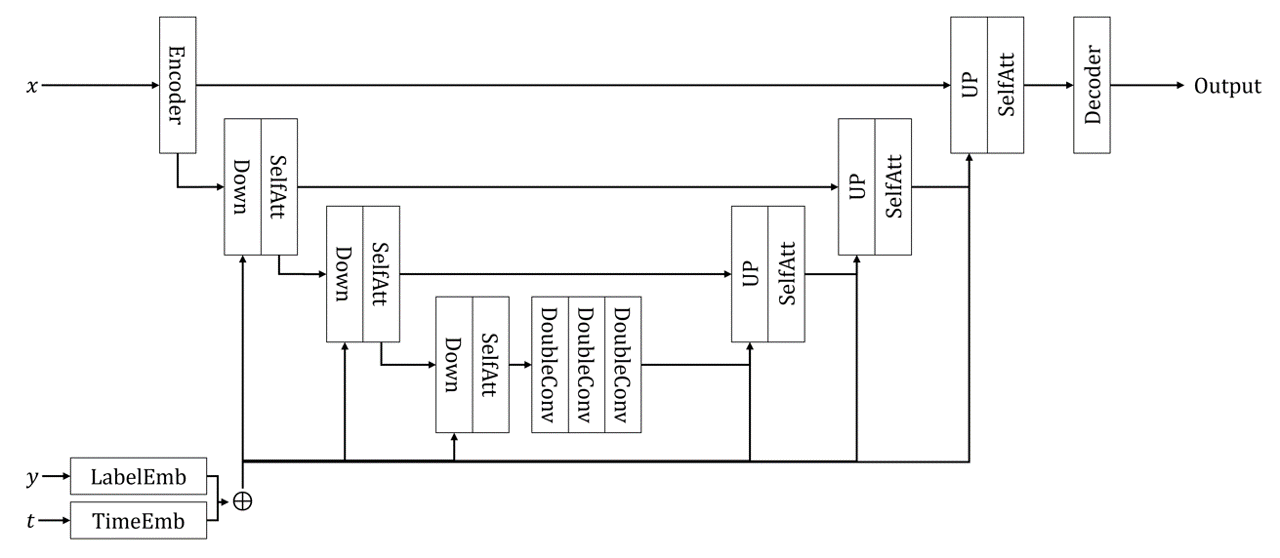

In [ ]:
class PositionalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0])) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size)).to(device)
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, mid_c = None, residual=False):
        super().__init__()
        self.residual = residual
        if not mid_c:
            mid_c = out_c
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_c, mid_c, kernel_size = 3, padding = 1, bias=False),
            nn.GroupNorm(1, mid_c),
            nn.GELU(),
            nn.Conv2d(mid_c, out_c, kernel_size = 3, padding = 1, bias=False),
            nn.GroupNorm(1, out_c)
        )
    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_c, out_c, emb_dim=256):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_c, in_c, residual=True),
            DoubleConv(in_c,out_c)
        )
        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_c)
        )
    def forward(self, x, t):
        x = self.maxpool_conv(x)
        emb = self.emb_layer(t)[:,:,None,None].repeat(1,1,x.shape[-2],x.shape[-1])
        return x + emb

class Up(nn.Module):
    def __init__(self, in_c, out_c, emb_dim=256):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            DoubleConv(in_c, in_c, residual=True),
            DoubleConv(in_c,out_c,in_c//2)
        )
        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_c)
        )
    def forward(self, x, skip_x, t):
        x= self.up(x)
        x = torch.cat([skip_x,x],dim=1)
        x = self.conv(x)
        emb = self.emb_layer(t)[:,:,None,None].repeat(1,1,x.shape[-2],x.shape[-1])
        return x + emb

class SelfAttention(nn.Module):
    def __init__(self, channels, size):
        super().__init__()
        self.channels, self.size = channels, size
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels)
        )
    def forward(self, x):
        x = x.view(-1, self.channels, self.size*self.size).swapaxes(1,2)
        x_ln = self.ln(x)
        attention_value, _ = self.mha(x_ln,x_ln,x_ln)
        attention_value = attention_value * x
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.swapaxes(2,1).view(-1, self.channels, self.size, self.size)

class UNet(nn.Module):
    def __init__(self, num_classes=10, time_dim=256):
        super().__init__()
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.time_dim =  time_dim
        self.time_mlp = PositionalEmbedding(256, 1.0).to(self.device)
        self.encoder_input = DoubleConv(1, 64)
        self.encoder_downsample1 = Down(64,128)
        self.encoder_attention1 = SelfAttention(128,16)
        self.encoder_downsample2 = Down(128,256)
        self.encoder_attention2 = SelfAttention(256,8)
        self.encoder_downsample3 = Down(256, 256)
        self.encoder_attention3 = SelfAttention(256, 4)

        self.conv1 = DoubleConv(256,512)
        self.conv2 = DoubleConv(512,512)
        self.conv3 = DoubleConv(512,256)

        self.decoder_upsample1 = Up(512, 128)
        self.decoder_attention1 = SelfAttention(128, 8)
        self.decoder_upsample2 = Up(256, 64)
        self.decoder_attention2 = SelfAttention(64, 16)
        self.decoder_upsample3 = Up(128, 64)
        self.decoder_attention3 = SelfAttention(64, 32)
        self.decoder_output = nn.Conv2d(64, 1, kernel_size = 1)

        if num_classes is not None:
            self.label_emb = nn.Embedding(num_classes, time_dim)

    def forward(self, x, t,y=None):
        t = self.time_mlp(t)

        if y is not None:
            t += self.label_emb(y)

        x1 = self.encoder_input(x)
        x2 = self.encoder_downsample1(x1,t)
        x2 = self.encoder_attention1(x2)
        x3 = self.encoder_downsample2(x2, t)
        x3 = self.encoder_attention2(x3)
        x4 = self.encoder_downsample3(x3, t)
        x4 = self.encoder_attention3(x4)

        x4 = self.conv1(x4)
        x4 = self.conv2(x4)
        x4 = self.conv3(x4)

        x3 = self.decoder_upsample1(x4, x3, t)
        x3 = self.decoder_attention1(x3)
        x2 = self.decoder_upsample2(x3, x2, t)
        x2 = self.decoder_attention2(x2)
        x1 = self.decoder_upsample3(x2, x1, t)
        x = self.decoder_attention3(x1)
        return self.decoder_output(x)


#### 2.3. Construct Conditional Denoising Diffusion Probabilistic Model (cddpm)

Now we create a new cddpm class which inherits ddpm and make some changes so that we can handle the image data:
1. change the num_timesteps to 1000 because now we are generating more complicated images.
2. Previously we expand the dimension of the parameters to be the same as the input data by `[:,None]`, now you have to modify this by overwriting the ``_init_dim`` method

In [ ]:
class cddpm(ddpm):
    def __init__(self,
                 num_timesteps=1000,
                 beta_start=0.0001,
                 beta_end=0.02,
                 beta_schedule='linear'
                 ):
        super().__init__(num_timesteps, beta_start, beta_end, beta_schedule)  # call constructor of ddpm, which does everything for us
    
    # TODO:
    def _init_dim(self):
        

#### 2.4. Training and Sampling

Now we have the denoising UNet model and the cddpm. It's time to train the model and visualize the result.

What you need to do:


*   Initialize the UNet model. Don't forget to put the model on GPU.

*   Initialize the Conditional DDPM

*   Initialize Optimizer

*   Implement training loop

Train the model with loss: $\mathcal{L} = \sum\|\epsilon_\theta(x_t, t, y) - \epsilon\|^2$

After each training epoch check the sampling quality.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define Model and put the model to GPU
model = ...

# Initialize CDDPM
diffusion = ...

# Initialize Optimizer
optimizer = ...

save_images_step = 1
num_epochs = 5
eval_batch_size = 20
img_size = 32 # 32 works better for the UNET
print("Training model...")

# Train
for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(tqdm(dataloader)):
        images, labels = images.to(device), labels.to(device)
        # randomly sample 'noise' that has the same dimension as 'images'
        # hint: you may want to use function 'torch.randn_like'
        noise = ...
        # randomly sample timesteps 't' for each image in the batch
        # hint: you may want to use the function 'sample_timesteps' we defined in class cddpm
        # hint: use .shape[0] to get the batch size
        # don't forget to put timesteps 't on GPU
        t = ...
        # add noise to the clean image according to the timesteps 't' we sampled
        # hint: you may want to use the function 'add_noise' we defined in class cddpm
        x_t = ...
        # predict the noise based on the noise image, the timestep, and the labels by the Unet we defined
        predicted_noise = ...
        # compute a loss between the randomly sampled noise and the predicted noise
        # hint: you may want to use function F.mse_loss
        loss = ...
        # TODO: complete the rest by .backward(), .step(), .zero_grad()

    # Sampling
    if epoch % save_images_step == 0 or epoch == num_epochs - 1:
        model.eval()
        labels = torch.tensor([0,0,1,1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9]).to(device)
        with torch.no_grad():
            # randomly sample 'noise' that has the dimension [eval_batch_size, 1, img_size, img_size]
            # this will be the starting point of our sampling i.e. x_T
            # don't forget to put this on the GPU
            x_t = torch.randn((eval_batch_size, 1, img_size, img_size)).to(device)
            for i in tqdm(list(reversed(range(1, diffusion.num_timesteps + 1)))):
                t = (torch.ones(eval_batch_size) * i).long().to(device)
                # predict the noise based on the current noise image, the timestep, and the labels by the Unet we defined
                # hint: to predict the noise, the timestep shoule be the same dimension as the input batch, think about whether to use 't' or 'i' here
                predicted_noise = ...
                # given the predicted noise and the current timestep and the current noise image, we are able to step one timestep backward
                # hint: you may want to use the function 'step' we defined in class cddpm
                # hint: the timestep in function 'step' shoule be a scalar, think about whether to use 't' or 'i' here
                x_t = ...
            x_t = (x_t.clamp(-1,1) + 1)/2
            show_images(x_t)

In [ ]:
model.eval()
labels = torch.tensor([0,0,0,0,0,0,0,0,0,0,
                       1,1,1,1,1,1,1,1,1,1,
                       2,2,2,2,2,2,2,2,2,2,
                       3,3,3,3,3,3,3,3,3,3,
                       4,4,4,4,4,4,4,4,4,4,
                       5,5,5,5,5,5,5,5,5,5,
                       6,6,6,6,6,6,6,6,6,6,
                       7,7,7,7,7,7,7,7,7,7,
                       8,8,8,8,8,8,8,8,8,8,
                       9,9,9,9,9,9,9,9,9,9]).to(device)
eval_batch_size = labels.shape[0]

with torch.no_grad():
    # randomly sample 'noise' that has the dimension [eval_batch_size, 1, img_size, img_size]
    # this will be the starting point of our sampling i.e. x_T
    # don't forget to put this on the GPU
    x_t = torch.randn((eval_batch_size, 1, img_size, img_size)).to(device)
    for i in tqdm(list(reversed(range(1, diffusion.num_timesteps + 1)))):   
        t = (torch.ones(eval_batch_size) * i).long().to(device)
        # predict the noise based on the current noise image, the timestep, and the labels by the Unet we defined
        # hint: to predict the noise, the timestep shoule be the same dimension as the input batch, think about whether to use 't' or 'i' here
        predicted_noise = ...
        # given the predicted noise and the current timestep and the current noise image, we are able to step one timestep backward
        # hint: you may want to use the function 'step' we defined in class cddpm
        # hint: the timestep in function 'step' shoule be a scalar, think about whether to use 't' or 'i' here
        x_t = ...
    x_t = (x_t.clamp(-1,1) + 1)/2
    show_images(x_t)

Note that the images should be one number per row as we are doing conditional generation.

**Demo 3:** Show the results to your TA. Summarize and explain what you have done!

## Reflection:

Developing new technology is often a double-edged sword. Considering the use-case of generation models , what are potential positive and negative impacts to society?

**Your thoughts:**